In [14]:
%matplotlib widget

In [15]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import empymod 
from scipy.constants import mu_0
import pygimli as pg
from pygimli.viewer.mpl import drawModel1D
from sklearn.metrics import root_mean_squared_error
from numpy import linalg as LA
from itertools import product
import plotly.express as px
import pandas as pd
from mpl_toolkits.mplot3d import axes3d
import matplotlib.colors as colors
import random

import sys

sys.path.insert(1, '../src')

from FDEM import FDEM, FDEM_1D


# Create equivalent models

In [23]:
# Define EC of first layer in mS/m
sigma_1 = np.logspace(2,3, 1000)

# EC of second layer with constant ratios
sigma_2 = sigma_1 / 10

# Define a constant product of sigma_1 * thick_1
product_s1t1 = 50

# Define thickness of first layer in meters
thick_1 = product_s1t1 / (np.sqrt(sigma_1))

# Create the models array (EC in S/m)

models_1 =np.array([ thick_1, sigma_1/1000, sigma_2/1000]).T

In [24]:
sigma_12 = sigma_1 / 1.2
sigma_22 = sigma_1 / 9
thick_12 = 500 / sigma_1
models_2 =np.array([ thick_12, sigma_12/1000, sigma_22/1000]).T

In [25]:
sigma_13 = sigma_1 /1.3
sigma_23 = sigma_1 / 8
thick_13 = 500 / sigma_1
models_3 =np.array([ thick_13, sigma_13/1000, sigma_23/1000]).T

In [26]:
sigma_14 = sigma_1 /1.4
sigma_24 = sigma_1 / 7
thick_14 = 500 / sigma_1
models_4 =np.array([ thick_14, sigma_14/1000, sigma_24/1000]).T

In [27]:
sigma_15 = sigma_1 /1.5
sigma_25 = sigma_1 / 6
thick_15 = 500 / sigma_1
models_5 =np.array([ thick_15, sigma_15/1000, sigma_25/1000]).T

Text(0.5, 0, '$\\sigma_2$')

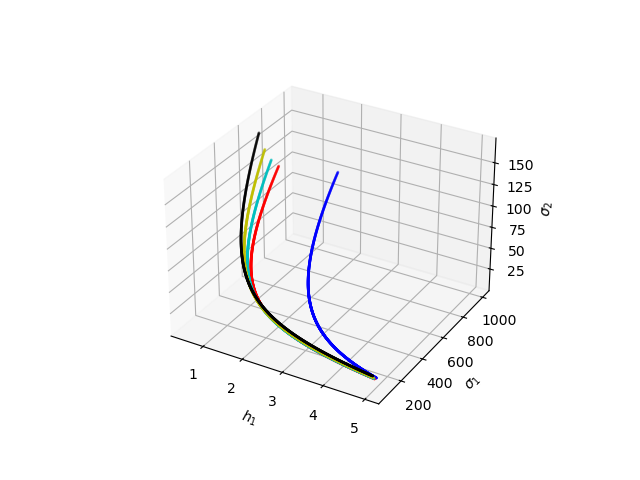

In [28]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

ax.scatter(models_1[:,0], models_1[:,1]*1000, models_1[:,2]*1000, s=1, c='b')
ax.scatter(models_2[:,0], models_2[:,1]*1000, models_2[:,2]*1000, s=1, c='r')
ax.scatter(models_3[:,0], models_3[:,1]*1000, models_3[:,2]*1000, s=1, c='c')
ax.scatter(models_4[:,0], models_4[:,1]*1000, models_4[:,2]*1000, s=1, c='y')
ax.scatter(models_5[:,0], models_5[:,1]*1000, models_5[:,2]*1000, s=1, c='k')


ax.set_xlabel('$h_1$')
ax.set_ylabel('$\sigma_1$')
ax.set_zlabel('$\sigma_2$')

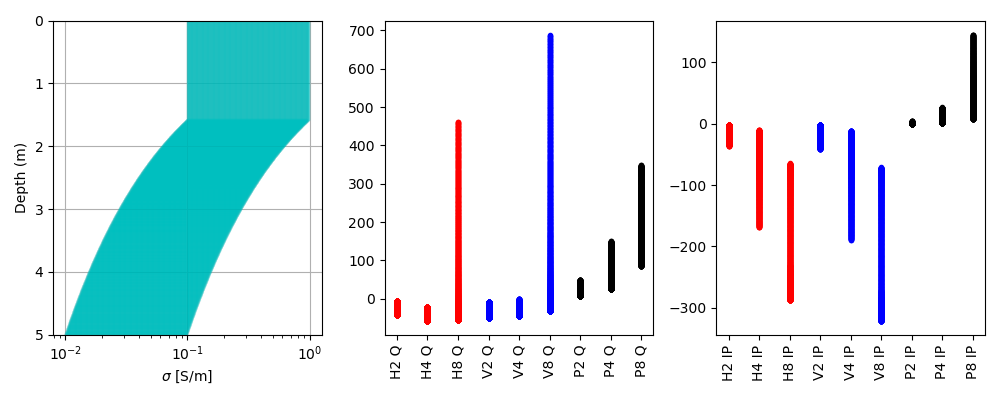

In [29]:
fig, ax = plt.subplots(1,3, figsize =(10,4))

xticks1 = ['H2 Q', 'H4 Q', 'H8 Q', 'V2 Q', 'V4 Q', 'V8 Q','P2 Q', 'P4 Q', 'P8 Q',]
xticks2 = ['H2 IP', 'H4 IP', 'H8 IP', 'V2 IP', 'V4 IP', 'V8 IP', 'P2 IP', 'P4 IP', 'P8 IP' ]

for m in models_1:
    drawModel1D(ax[0], model=m, zmax=5, color='c', alpha=0.1, xlabel='$\sigma$ [S/m]')
    d = FDEM(m[1:], [m[0]])
    ax[1].plot([0,1,2], d[:3], '.r')   # HOP
    ax[2].plot([0,1,2], d[3:6], '.r')  # HIP
    ax[1].plot([3,4,5], d[6:9], '.b')  # VOP
    ax[2].plot([3,4,5], d[9:12], '.b') # VIP
    ax[1].plot([6,7,8], d[12:15], '.k') # POP
    ax[2].plot([6,7,8], d[15:], '.k')   # PIP
    
ax[1].set_xticks(range(len(d[:9])), labels=xticks1, rotation = 90)
ax[2].set_xticks(range(len(d[9:])), labels=xticks2, rotation = 90)

ax[0].set_xscale('log')
plt.tight_layout()

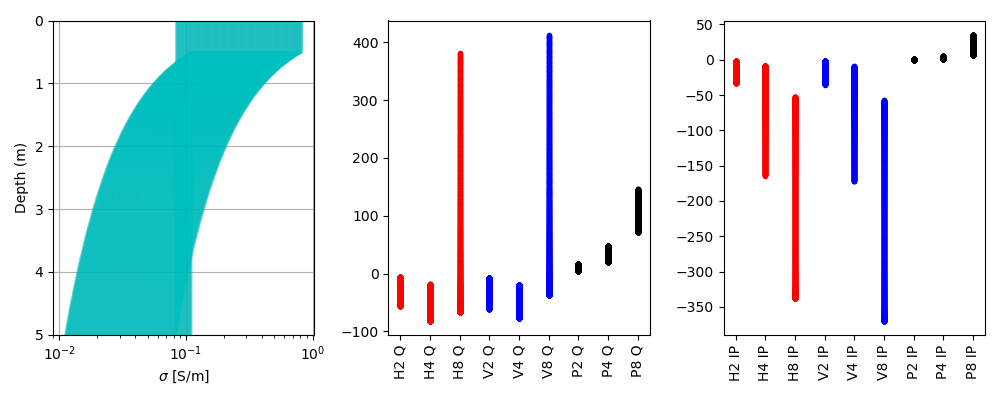

In [10]:
fig, ax = plt.subplots(1,3, figsize =(10,4))

xticks1 = ['H2 Q', 'H4 Q', 'H8 Q', 'V2 Q', 'V4 Q', 'V8 Q','P2 Q', 'P4 Q', 'P8 Q',]
xticks2 = ['H2 IP', 'H4 IP', 'H8 IP', 'V2 IP', 'V4 IP', 'V8 IP', 'P2 IP', 'P4 IP', 'P8 IP' ]

for m in models_2:
    drawModel1D(ax[0], model=m, zmax=5, color='c', alpha=0.1, xlabel='$\sigma$ [S/m]')
    d = FDEM(m[1:], [m[0]])
    ax[1].plot([0,1,2], d[:3], '.r')   # HOP
    ax[2].plot([0,1,2], d[3:6], '.r')  # HIP
    ax[1].plot([3,4,5], d[6:9], '.b')  # VOP
    ax[2].plot([3,4,5], d[9:12], '.b') # VIP
    ax[1].plot([6,7,8], d[12:15], '.k') # POP
    ax[2].plot([6,7,8], d[15:], '.k')   # PIP
    
ax[1].set_xticks(range(len(d[:9])), labels=xticks1, rotation = 90)
ax[2].set_xticks(range(len(d[9:])), labels=xticks2, rotation = 90)

ax[0].set_xscale('log')
plt.tight_layout()

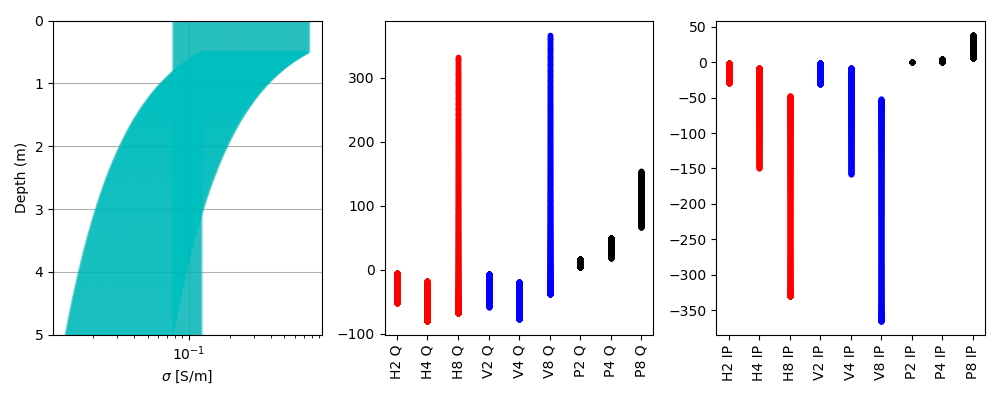

In [11]:
fig, ax = plt.subplots(1,3, figsize =(10,4))

xticks1 = ['H2 Q', 'H4 Q', 'H8 Q', 'V2 Q', 'V4 Q', 'V8 Q','P2 Q', 'P4 Q', 'P8 Q',]
xticks2 = ['H2 IP', 'H4 IP', 'H8 IP', 'V2 IP', 'V4 IP', 'V8 IP', 'P2 IP', 'P4 IP', 'P8 IP' ]

for m in models_3:
    drawModel1D(ax[0], model=m, zmax=5, color='c', alpha=0.1, xlabel='$\sigma$ [S/m]')
    d = FDEM(m[1:], [m[0]])
    ax[1].plot([0,1,2], d[:3], '.r')   # HOP
    ax[2].plot([0,1,2], d[3:6], '.r')  # HIP
    ax[1].plot([3,4,5], d[6:9], '.b')  # VOP
    ax[2].plot([3,4,5], d[9:12], '.b') # VIP
    ax[1].plot([6,7,8], d[12:15], '.k') # POP
    ax[2].plot([6,7,8], d[15:], '.k')   # PIP
    
ax[1].set_xticks(range(len(d[:9])), labels=xticks1, rotation = 90)
ax[2].set_xticks(range(len(d[9:])), labels=xticks2, rotation = 90)

ax[0].set_xscale('log')
plt.tight_layout()

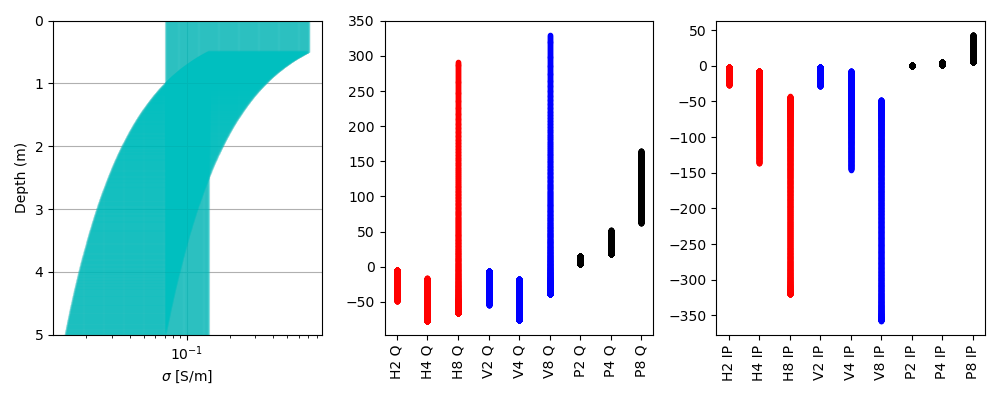

In [12]:
fig, ax = plt.subplots(1,3, figsize =(10,4))

xticks1 = ['H2 Q', 'H4 Q', 'H8 Q', 'V2 Q', 'V4 Q', 'V8 Q','P2 Q', 'P4 Q', 'P8 Q',]
xticks2 = ['H2 IP', 'H4 IP', 'H8 IP', 'V2 IP', 'V4 IP', 'V8 IP', 'P2 IP', 'P4 IP', 'P8 IP' ]

for m in models_4:
    drawModel1D(ax[0], model=m, zmax=5, color='c', alpha=0.1, xlabel='$\sigma$ [S/m]')
    d = FDEM(m[1:], [m[0]])
    ax[1].plot([0,1,2], d[:3], '.r')   # HOP
    ax[2].plot([0,1,2], d[3:6], '.r')  # HIP
    ax[1].plot([3,4,5], d[6:9], '.b')  # VOP
    ax[2].plot([3,4,5], d[9:12], '.b') # VIP
    ax[1].plot([6,7,8], d[12:15], '.k') # POP
    ax[2].plot([6,7,8], d[15:], '.k')   # PIP
    
ax[1].set_xticks(range(len(d[:9])), labels=xticks1, rotation = 90)
ax[2].set_xticks(range(len(d[9:])), labels=xticks2, rotation = 90)

ax[0].set_xscale('log')
plt.tight_layout()

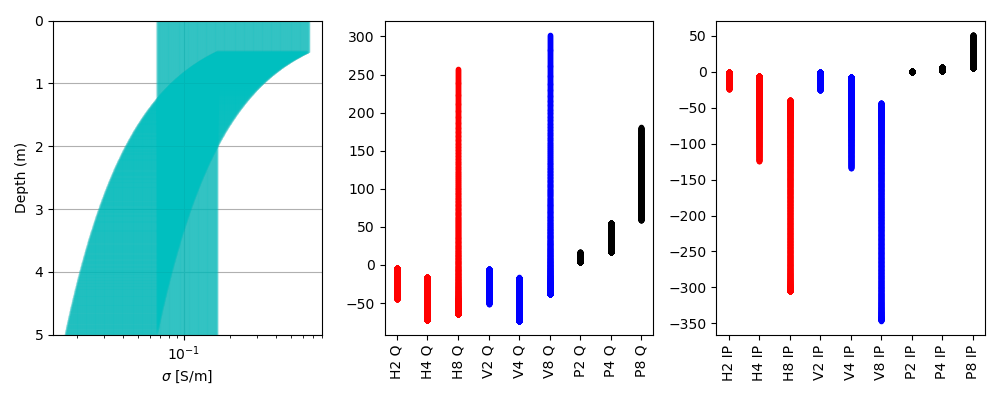

In [13]:
fig, ax = plt.subplots(1,3, figsize =(10,4))

xticks1 = ['H2 Q', 'H4 Q', 'H8 Q', 'V2 Q', 'V4 Q', 'V8 Q','P2 Q', 'P4 Q', 'P8 Q',]
xticks2 = ['H2 IP', 'H4 IP', 'H8 IP', 'V2 IP', 'V4 IP', 'V8 IP', 'P2 IP', 'P4 IP', 'P8 IP' ]

for m in models_5:
    drawModel1D(ax[0], model=m, zmax=5, color='c', alpha=0.1, xlabel='$\sigma$ [S/m]')
    d = FDEM(m[1:], [m[0]])
    ax[1].plot([0,1,2], d[:3], '.r')   # HOP
    ax[2].plot([0,1,2], d[3:6], '.r')  # HIP
    ax[1].plot([3,4,5], d[6:9], '.b')  # VOP
    ax[2].plot([3,4,5], d[9:12], '.b') # VIP
    ax[1].plot([6,7,8], d[12:15], '.k') # POP
    ax[2].plot([6,7,8], d[15:], '.k')   # PIP
    
ax[1].set_xticks(range(len(d[:9])), labels=xticks1, rotation = 90)
ax[2].set_xticks(range(len(d[9:])), labels=xticks2, rotation = 90)

ax[0].set_xscale('log')
plt.tight_layout()

In [33]:
# Store the models

np.save('Models/Equi_models_UC_1', models_1)
np.save('Models/Equi_models_UC_2', models_2)
np.save('Models/Equi_models_UC_3', models_3)
np.save('Models/Equi_models_UC_4', models_4)
np.save('Models/Equi_models_UC_5', models_5)
